# Rail Corrugation
## Spatial Feature Experiment

This notebook evaluates whether axle-position and car-level spatial information improves the existing vibration baseline.

Experiments:
1. Baseline
2. Position-pair differences
3. Position-pair differences and ratios
4. Car-level side asymmetry
5. Combined spatial representation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

DATA_DIR = Path("..")
TRAIN_PATH = DATA_DIR / "Train"

labels = pd.read_csv(DATA_DIR / "Train_Labels.csv")
baseline = pd.read_csv(DATA_DIR / "rail_features.csv")

sample = pd.read_csv(TRAIN_PATH / "Train1.csv")

vib_cols = [c for c in sample.columns if "vibration" in c.lower()]

In [2]:
X_base = baseline.drop(columns=["filename", "label"])
y = baseline["label"]

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

rf = RandomForestClassifier(
    n_estimators=500,
    class_weight="balanced",
    random_state=42
)

In [3]:
base_scores = cross_val_score(
    rf, X_base, y,
    cv=cv,
    scoring="f1_macro"
)

print(base_scores.round(3))
print("Baseline:", base_scores.mean().round(3))

[0.725 0.652 0.779 0.756 0.666]
Baseline: 0.716


In [4]:
base_scores = cross_val_score(
    rf, X_base, y,
    cv=cv,
    scoring="f1_macro"
)

print(base_scores.round(3))
print("Baseline:", base_scores.mean().round(3))

[0.725 0.652 0.779 0.756 0.666]
Baseline: 0.716


## 1. Position-Pair Differences

The spatial analysis showed systematic differences between corresponding Side I and Side II axle positions.

For each recording we calculate:

- Position 1 − Position 2
- Position 3 − Position 4
- Position 5 − Position 6
- Position 7 − Position 8

In [5]:
def axle_rms(data):
    return {
        col: np.sqrt(np.mean(data[col].to_numpy() ** 2))
        for col in vib_cols
    }

In [6]:
rows = []

for _, row in labels.iterrows():
    data = pd.read_csv(TRAIN_PATH / row["filename"])
    rms = axle_rms(data)

    features = {}

    for p1, p2 in [(1, 2), (3, 4), (5, 6), (7, 8)]:
        cols1 = [c for c in vib_cols if f"position {p1} " in c.lower()]
        cols2 = [c for c in vib_cols if f"position {p2} " in c.lower()]

        v1 = np.mean([rms[c] for c in cols1])
        v2 = np.mean([rms[c] for c in cols2])

        features[f"pair_{p1}_{p2}_diff"] = v1 - v2

    rows.append(features)

pair_diff = pd.DataFrame(rows)

In [7]:
X_pair = pd.concat(
    [X_base.reset_index(drop=True), pair_diff],
    axis=1
)

pair_scores = cross_val_score(
    rf, X_pair, y,
    cv=cv,
    scoring="f1_macro"
)

print(pair_scores.round(3))
print("Baseline + Pair Differences:", pair_scores.mean().round(3))

[0.725 0.652 0.752 0.71  0.727]
Baseline + Pair Differences: 0.713


## 2. Position-Pair Ratios

Ratios provide a scale-normalised measure of asymmetry between corresponding Side I and Side II positions.

In [9]:
rows = []

for _, row in labels.iterrows():
    data = pd.read_csv(TRAIN_PATH / row["filename"])
    rms = axle_rms(data)

    features = {}

    for p1, p2 in [(1, 2), (3, 4), (5, 6), (7, 8)]:
        cols1 = [c for c in vib_cols if f"position {p1} " in c.lower()]
        cols2 = [c for c in vib_cols if f"position {p2} " in c.lower()]

        v1 = np.mean([rms[c] for c in cols1])
        v2 = np.mean([rms[c] for c in cols2])

        features[f"pair_{p1}_{p2}_ratio"] = v1 / v2

    rows.append(features)

pair_ratio = pd.DataFrame(rows)

In [10]:
X_pair_ratio = pd.concat(
    [X_pair, pair_ratio],
    axis=1
)

ratio_scores = cross_val_score(
    rf, X_pair_ratio, y,
    cv=cv,
    scoring="f1_macro"
)

print(ratio_scores.round(3))
print("Differences + Ratios:", ratio_scores.mean().round(3))

[0.697 0.639 0.812 0.71  0.727]
Differences + Ratios: 0.717


## 3. Car-Level Side Asymmetry

For each of the eight cars, vibration RMS is aggregated separately for Side I and Side II.

The difference between both sides is then retained as one feature per car.

In [11]:
side1_positions = [1, 3, 5, 7]
side2_positions = [2, 4, 6, 8]

rows = []

for _, row in labels.iterrows():
    data = pd.read_csv(TRAIN_PATH / row["filename"])
    rms = axle_rms(data)

    features = {}

    for car in range(1, 9):
        s1 = [
            rms[c] for c in vib_cols
            if c.lower().endswith(f"car {car}")
            and any(f"position {p} " in c.lower() for p in side1_positions)
        ]

        s2 = [
            rms[c] for c in vib_cols
            if c.lower().endswith(f"car {car}")
            and any(f"position {p} " in c.lower() for p in side2_positions)
        ]

        features[f"car_{car}_diff"] = np.mean(s1) - np.mean(s2)

    rows.append(features)

car_diff = pd.DataFrame(rows)

In [12]:
display(car_diff.head())

,car_1_diff,car_2_diff,car_3_diff,car_4_diff,car_5_diff,car_6_diff,car_7_diff,car_8_diff
0,0.067230,0.059204,-0.019839,0.052793,-0.052641,0.036492,-0.015316,0.015806
1,0.172474,0.152599,0.415339,-0.428340,0.438251,-0.827369,-0.016750,-0.097534
2,-0.042806,-0.136563,0.114567,-0.061836,0.036472,-0.205697,0.202646,-0.039053
3,-0.010906,-0.184212,-0.038314,0.091644,-0.104338,-0.025487,0.095499,-0.536023
4,0.004742,0.003978,0.040198,0.043761,-0.005372,-0.000569,0.018521,0.023171


In [13]:
X_car = pd.concat(
    [X_base.reset_index(drop=True), car_diff],
    axis=1
)

car_scores = cross_val_score(
    rf, X_car, y,
    cv=cv,
    scoring="f1_macro"
)

print(car_scores.round(3))
print("Baseline + Car Differences:", car_scores.mean().round(3))

[0.668 0.652 0.815 0.71  0.735]
Baseline + Car Differences: 0.716


In [14]:
X_spatial = pd.concat(
    [
        X_base.reset_index(drop=True),
        pair_diff,
        pair_ratio,
        car_diff
    ],
    axis=1
)

spatial_scores = cross_val_score(
    rf, X_spatial, y,
    cv=cv,
    scoring="f1_macro"
)

print(spatial_scores.round(3))
print("Combined Spatial:", spatial_scores.mean().round(3))

[0.668 0.639 0.845 0.71  0.79 ]
Combined Spatial: 0.731


In [15]:
results = pd.DataFrame({
    "Baseline": base_scores,
    "Pair Diff": pair_scores,
    "Pair Diff + Ratio": ratio_scores,
    "Car Diff": car_scores,
    "Combined Spatial": spatial_scores
})

display(results)

,Baseline,Pair Diff,Pair Diff + Ratio,Car Diff,Combined Spatial
0,0.724755,0.724755,0.697133,0.668056,0.668056
1,0.652482,0.652482,0.639486,0.652482,0.639486
2,0.779487,0.752482,0.811696,0.814976,0.844907
3,0.755871,0.710375,0.710375,0.710375,0.710375
4,0.665633,0.727305,0.727305,0.734796,0.790404


In [16]:
summary = pd.DataFrame({
    "Mean Macro F1": results.mean(),
    "Std": results.std()
})

display(summary.sort_values("Mean Macro F1", ascending=False))

,Mean Macro F1,Std
Combined Spatial,0.730646,0.085535
Pair Diff + Ratio,0.717199,0.062290
Car Diff,0.716137,0.064254
Baseline,0.715646,0.055380
Pair Diff,0.713480,0.037316


## Per-Class Performance

Because Side I is currently the weakest class, the strongest spatial representation is evaluated using out-of-fold predictions.

In [17]:
best_X = X_spatial

pred = cross_val_predict(
    rf,
    best_X,
    y,
    cv=cv
)

print(classification_report(y, pred, digits=3))

              precision    recall  f1-score   support

      Normal      0.961     0.949     0.955       234
      Side I      0.389     0.500     0.438        14
     Side II      0.783     0.750     0.766        24

    accuracy                          0.908       272
   macro avg      0.711     0.733     0.719       272
weighted avg      0.916     0.908     0.912       272



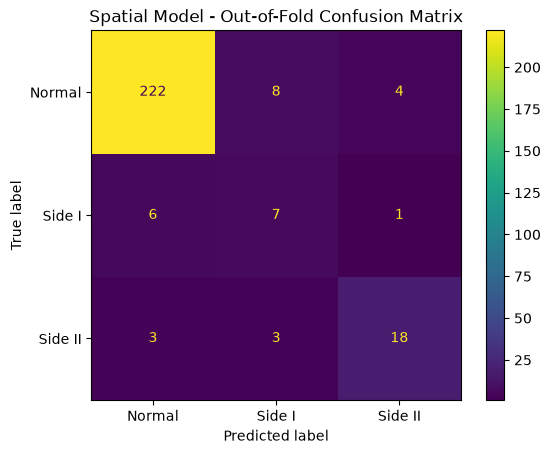

In [18]:
ConfusionMatrixDisplay.from_predictions(y, pred)

plt.title("Spatial Model - Out-of-Fold Confusion Matrix")
plt.show()